In [1]:
#import relevant libraries
import numpy as np
import seaborn as sns
import random
import math
import cmath
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation

from matplotlib.colors import ListedColormap
from IPython.display import HTML
from collections import defaultdict

from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
#functions

#function generates lattice of 1s and 0s; 1 means there's a firefly there, 0 means it's empty
def lattice(rows, cols, prop_one): #prop_one is proportion of ones
    tot_cells = rows * cols
    num_ones = int(tot_cells * prop_one)

    arr = np.zeros((rows, cols))

    ind_ones = np.random.choice(tot_cells, num_ones, replace = False)
    row_ind = ind_ones // cols
    col_ind = ind_ones % cols

    arr[row_ind, col_ind] = 1

    return arr

#function generates list of firefly phases between 0 and 2pi 
def phase_list(num_ff):
    phases = []
    while len(phases) < num_ff:
        phase = random.uniform(0, 2 * math.pi)
        if phase != 0 and phase != 2 * math.pi:
            phases.append(phase)
    return phases

#function assigns non-empty lattice positions to firefly phases from list
def phase_arr(positions, phases):
    phase_array = np.zeros_like(positions)
    occ_indices = np.argwhere(positions) #list of indices with non-zero entries

    count = 0

    for i, j in occ_indices:
        phase_array[i, j] = phases[count]
        count = count + 1
    return phase_array          

def strat_arr(positions, propC):
    total_nonzero = np.count_nonzero(positions)
    num_coop = int(total_nonzero * propC)
    num_def = total_nonzero - num_coop
    
    strat_arr = np.zeros_like(positions)
    nonzero_indices = np.nonzero(positions)

    indices_coop = np.random.choice(range(total_nonzero), size = num_coop, replace = False)
    indices_coop.astype(np.int64)

    indices_def = np.random.choice(np.array([x for x in range(total_nonzero) if x not in indices_coop.tolist()]), size = num_def, replace = False)
    indices_def.astype(np.int64)
    
    strat_arr[nonzero_indices[0][indices_coop], nonzero_indices[1][indices_coop]] = -1
    strat_arr[nonzero_indices[0][indices_def], nonzero_indices[1][indices_def]] = -2

    return strat_arr

#alternate strat assigning function
def altstrat(positions, propC):
    num_nz = np.count_nonzero(positions)
    num_coop = int(num_nz * propC)
    num_def = num_nz - num_coop

    altstrat = np.zeros_like(positions)
    nz_indices = np.argwhere(positions)
    ord_pairs = [tuple(index) for index in nz_indices]

    indices_coop = np.random.choice(len(ord_pairs), size = num_coop, replace = False)
    loc_coop = [ord_pairs[index_coop] for index_coop in indices_coop]

    rem_pairs = [pair for pair in ord_pairs if pair not in loc_coop]
    indices_def = np.random.choice(len(rem_pairs), size = num_def, replace = False)
    loc_def = [rem_pairs[index_def] for index_def in indices_def]

    for i, j in loc_coop:
        altstrat[i, j] = -1
    
    for i, j in loc_def:
        altstrat[i, j] = -2
    
    return altstrat

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def coh(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/len(compexp_list)
    return phaseorder

#function gives phase-order (absolute value of sum of non-zero phasors/number of non-zero phasors) of phase list
def cohs(numlist):
    compexp_list = [cmath.exp(1j * x) for x in numlist]
    total = abs(sum(compexp_list))
    phaseorder = total/9
    return phaseorder

#function gives list of phases of focal cell and its non-zero neighbors
def neighbors(a, radius, r, c):
    numlist = [ a[i, j] if  i >= 0 and i < len(a) and j >= 0 and j < len(a[0]) else 0
                for j in range(c - 1 - radius, c + radius)
                    for i in range(r - 1 - radius, r + radius) ]
    non_zero_nghbrs = [x for x in numlist if x != 0]
    return non_zero_nghbrs

#function generates payoff array, ones in the bulk can have a maximum of 8 neighbors so maxbright = 1.
#ones on the sides can have max 5 neighbors so maxbright = 6/9 = 2/3
#ones on the corners can have max 3 neighbors so maxbright = 4/9
def payoff_arr(ph_arr, strat_arr, rang):
    pay = np.zeros_like(ph_arr)
    filled_indices = np.argwhere(ph_arr)

    for i, j in filled_indices:
        k = neighbors(ph_arr, rang, i + 1, j + 1)
        if strat_arr[i, j] == -1:
            pay[i, j] = cohs(k)
        else:
            pay[i, j] = cohs(k) + cost
    return pay
       
#kuramoto
def kur3(phase, strat, r, K):
    phasenext = np.zeros_like(phase)
    fireflylocs = [(i, j) for i, j in np.argwhere(phase)]
    for i, j in fireflylocs:
        if strat[i, j] == -1:
            nehbrs = neighbors(phase, r, i + 1, j + 1)
            templist = [np.sin(nehbr - phase[i, j]) for nehbr in nehbrs]
            cont = sum(templist)/len(templist)
            phasenext[i, j] = (phase[i, j] + (K * cont)) % (2 * math.pi)
        else:
            phasenext[i, j] = phase[i, j]
    return phasenext

#function that takes an array and a particular position index (row and column) and returns the list of empty indices in Moore neighborhood
def emptyneigh(arr, row, col):
    draft1 = [(row - 1, col - 1), (row - 1, col), (row - 1, col + 1), (row, col - 1), (row, col + 1), (row + 1, col - 1), (row + 1, col), (row + 1, col + 1)]
    draft2 = [(x, y) for x, y in draft1 if 0 <= x < arr.shape[0] and 0 <= y < arr.shape[1]]
    finaldraft = [(x, y) for x, y in draft2 if arr[x, y] == 0]
    return finaldraft

#function updates position, and carries phase and strat to new position too
def mov(phase, strat, old_pay, new_pay, k):
    pay_diff = np.subtract(new_pay, old_pay)
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        random_num = np.random.rand()
        prob = (1 + math.tanh(k * pay_diff[i, j]))/2 #probability of staying in same location
        if prob < random_num:
            neigbors = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
            neigbors_inbound = [(x, y) for x, y in neigbors if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
            neigbors_empty = [(x, y) for x, y in neigbors_inbound if strat[x, y] == 0]
            if neigbors_empty:
                new_i, new_j = neigbors_empty[np.random.randint(len(neigbors_empty))]
                phase[new_i, new_j] = phase[i, j] #print phases before and after
                strat[new_i, new_j] = strat[i, j]
                phase[i, j] = 0
                strat[i, j] = 0
    return phase, strat 

#alternate movement function
def mov2(phase, strat, pay):
    filled_indices = [(i, j) for i, j in np.argwhere(strat)]
    random.shuffle(filled_indices)

    for i, j in filled_indices:
        neig = [(i - 1, j - 1), (i - 1, j), (i - 1, j + 1), (i, j - 1), (i, j + 1), (i + 1, j - 1), (i + 1, j), (i + 1, j + 1)]
        neig_inbound = [(x, y) for x, y in neig if 0 <= x < strat.shape[0] and 0 <= y < strat.shape[1]]
        neig_empty = [(x, y) for x, y in neig_inbound if strat[x, y] == 0]
        if neig_empty:
            if strat[i, j] == -1:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]), (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
            if strat[i, j] == -2:
                payloc = [(cohs(neighbors(phase, 1, x + 1, y + 1) + [phase[i, j]]) + cost, (x, y)) for x, y in neig_empty]
                max_payloc = max(payloc, key=lambda item: item[0])
                if max_payloc[0] > pay[i, j]:
                    new_i, new_j = max_payloc[1]
                    phase[new_i, new_j] = phase[i, j]
                    strat[new_i, new_j] = strat[i, j]
                    phase[i, j] = 0
                    strat[i, j] = 0
    return phase, strat


#custom histogram function
def histo(phase, strat):
    #sorted phase lists
    coop = np.sort(phase[strat == -1])
    defc = np.sort(phase[strat == -2])

    #number of observations
    num_coop = len(coop)
    num_defc = len(defc)

    #find interquartile range (IQR) of phase distribution
    Q1_C = np.percentile(coop, 25)
    Q3_C = np.percentile(coop, 75)
    IQR_C = Q3_C - Q1_C
    #FD binning
    binw_C = (2 * IQR_C) / (num_coop ** (1. / 3))
    numbin_C = int((coop[-1] - coop[0]) / binw_C)

    Q1_D = np.percentile(defc, 25)
    Q3_D = np.percentile(defc, 75)
    IQR_D = Q3_D - Q1_D
    #FD binning
    binw_D = (2 * IQR_D) / (num_defc ** (1. / 3))
    numbin_D = int((defc[-1] - defc[0]) / binw_D)

    numbin = max(numbin_C, numbin_D)

    plt.hist([coop, defc], bins = numbin, label = ['cooperators','defectors'], stacked = True)
    plt.show


#function that plots stacked histogram of phase distibution given phase and strategy arrays        
def dist(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))
    bins = np.linspace(1e-10, 2 * np.pi, 50)

    lalalist1 = []
    lalalist2 = []

    for i, (phase, strat) in enumerate(numlist):
        coop = phase[strat == -1].tolist()
        defc = phase[strat == -2].tolist()

        lalalist1.append(defc)

        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]

        ax.hist([coop, defc], bins = bins, stacked = True, label = ['coop', 'def'])
        lalalist2.append(defc)

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.show()

    return lalalist1, lalalist2

#function that measures average neighborhood density of fireflies
def avgneigh(phase_array):
    numlist = []
    for i in range(len(phase_array)):
        for j in range(len(phase_array[0])):
            if phase_array[i, j] != 0:
                neigh = neighbors(phase_array, 1, i + 1, j + 1)
                density = (len(neigh) - 1)/8
                numlist.append(density)
            else:
                continue
    value = sum(numlist)/len(numlist)
    return value

#function that measures average density of cooperators in neighborhood: assortment checking function
def assort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1 - 1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of cooperators in neighborhood: assortment checking function
def cassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1 - 1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -1)
                density = (num_minus1) / (len(neigh) - 1) if len(neigh) > 1 else 0
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of defectors in neighborhood: assortment checking function
def dassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -2)
                density = (num_minus1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = sum(1 for n in neigh if n == -2)
                density = (num_minus1 - 1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that measures average density of empty space in neighborhood: assortment checking function
def eassort(strat_array):
    numlist1 = []
    numlist2 = []
    for i in range(len(strat_array)):
        for j in range(len(strat_array[0])):
            if strat_array[i, j] == -1:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = 9 - len(neigh)
                density = (num_minus1)/8
                numlist1.append(density)
            elif strat_array[i, j] == -2:
                neigh = neighbors(strat_array, 1, i + 1, j + 1)
                num_minus1 = 9 - len(neigh)
                density = (num_minus1)/8
                numlist2.append(density)
            else:
                continue
    value1 = sum(numlist1)/len(numlist1) if numlist1 else 0
    value2 = sum(numlist2)/len(numlist2) if numlist2 else 0
    return value1, value2

#function that spits out standard deviation of phase array
def stdev(phase):
    nonzvalues = phase[phase != 0]
    std_dev = np.std(nonzvalues)

    return std_dev
    

#function that calculates strategy independent spatial statistics of the phase array
def spatstat(phase):
    filled_indices = np.argwhere(phase != 0)
    im_func = 0
    im_count = 0
    nn_func = 0
    nn_count = 0
    edgecorr = 1
    for i, j in filled_indices:
        for p, q in filled_indices:
            testfunc = abs(phase[i, j] - phase[p, q]) #difference of phases is quantity of interest
            sqdist = ((i - p) ** 2) + ((j - q) ** 2)
            if sqdist == 1 or sqdist == 2: #if one filled index is in the immediate neighborhood of the other
                im_count += 1
                im_func += (testfunc * edgecorr)
            elif sqdist == 2 or sqdist == 5 or sqdist == 8: #if one filled index is in the next nearest neighborhood of the other
                nn_count += 1
                nn_func += (testfunc * edgecorr)

    im_val = im_func/im_count
    nn_val = nn_func/nn_count 
    return im_val, nn_val


#function that chooses (based on payoff values) a single male for mating
def mate_choice(payoff_array, strat_array):
    non_zero_sum = np.sum(payoff_array[payoff_array != 0]) #sum of payoffs
    mateprob_array = payoff_array / non_zero_sum #normalized fitness payoff, equal to mating probability

    non_zero_indices = np.transpose(np.nonzero(mateprob_array)) #indices of fireflies
    non_zero_values = mateprob_array[mateprob_array.nonzero()] #probabilities

    chosen_index = np.random.choice(len(non_zero_values), p = non_zero_values) #making random weighted choice
    chosen_indices = non_zero_indices[chosen_index] #index of chosen male

    chosen_strat = strat_array[chosen_indices[0], chosen_indices[1]] #strategy of chosen male

    return chosen_strat

#given payoff and strat arrays, function returns average phases of cooperators and defectors
def avgpay(payoff_array, strat_array):
    coop_avg = np.average(payoff_array[strat_array == -1])
    def_avg = np.average(payoff_array[strat_array == -2])

    return coop_avg, def_avg

#given payoff and strat arrays, function returns relative payoff of cooperators
def relcooppay(payoff_array, strat_array):
    coop_avg = np.sum(payoff_array[strat_array == -1])
    net_avg = np.sum(payoff_array)
    rel_coop = coop_avg / net_avg

    return rel_coop

#display heatmap of phases, with red gradient for cooperators and blue gradient for defectors
def disp_phase_and_strat(numlist):
    num_plots = len(numlist)
    num_cols = min(4, num_plots)
    num_rows = (num_plots - 1) // num_cols + 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize = (4 * num_cols, 4 * num_rows))

    cmap_red = plt.cm.get_cmap('Reds')
    norm_red = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    cmap_blue = plt.cm.get_cmap('Blues')
    norm_blue = mcolors.Normalize(vmin = 0, vmax = 2 * np.pi)

    for i, (phase, strat) in enumerate(numlist):
        row_index = i // num_cols
        col_index = i % num_cols

        ax = axes[row_index, col_index] if num_rows > 1 else axes[col_index]
        
        masked_phase_red = np.ma.masked_where(strat != -1, phase)
        masked_phase_blue = np.ma.masked_where(strat != -2, phase)

        ax.imshow(masked_phase_red, cmap = cmap_red, norm = norm_red, interpolation = 'nearest')
        ax.imshow(masked_phase_blue, cmap = cmap_blue, norm = norm_blue, interpolation = 'nearest')
        ax.set_title(f'Plot {i+1}')

    for i, ax in enumerate(axes.flatten()):
        if i >= num_plots:
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
    plt.show()    

#display mated_stratlist proportions in a pie chart
def piechart(numlist):
    counts = {val: numlist.count(val) for val in set(numlist)}
    
    labels = ['coop', 'def']
    sizes = [counts.get(-1, 0), counts.get(-2, 0)]
    colors = ['red', 'blue']

    plt.pie(sizes, labels = labels, colors = colors)
    plt.axis('equal')
    
    plt.show(block = False)
    plt.pause(0.001)

#find proportion of cooperators for next generation from matedstratlist of previous generation
def nextprop(prevlist):
    numcoop = prevlist.count(-1.0)
    propcoop = numcoop / len(prevlist)
    return propcoop

def globcoh(phase):
    nonzvalues = phase[phase != 0]
    glob_coh = coh(nonzvalues)

    return glob_coh

def avgloccoh(phase, rang):
    loccoh_list = []
    filled_indices = np.argwhere(phase)

    for i, j in filled_indices:
        k = neighbors(phase, rang, i + 1, j + 1)
        loccoh_list.append(coh(k))

    avgval = sum(loccoh_list)/len(loccoh_list)
    return avgval


In [4]:
#code for one night model
rootN = 20 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 10000 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
#nf = int(nm / 2) #number of female fireflies
#mate_timepoints = np.random.choice(repeats, nf, replace = False) #set of timepoints when female fireflies appear and mating happens, randomly chosen within the repeat range
#mate_timepoints.sort() #sorted list of timepoints

firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice

firstphaselist = phase_list(nm) #initial list of phases of the firelies

firstphase = phase_arr(firstpos, firstphaselist) #initial phase array

coopprop = 0.5 #proportion of cooperators
firststrat = altstrat(firstpos, coopprop) #initial strat array

cost = 0.05 #cost of cooperation
firstpay = payoff_arr(firstphase, firststrat, rang) #initial payoff array

#3d arrays for storing data of all timepoints
phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
strat3d = np.zeros((rootN, rootN, repeats + 1))

phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
strat3d[:, :, 0] = firststrat #same with strat

#matedlist = [] #list of mated strategies over the night
#paytimepoints = []

for i in range(repeats):
    
    #mating
    #if i in mate_timepoints: #if particular iteration matches one of the timepoints for females to show up,
        #matedlist.append((mate_choice(firstpay, firststrat), i)) #a male firefly is chosen for mating and its strategy is added to matedlist

    #avgcoop, avgdef = avgpay(firstpay, firststrat)
    #paytimepoints.append((i, avgcoop, avgdef))
 
    #phase update
    secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
    secondpay = payoff_arr(secondphase, firststrat, rang) #payoff array after kuramoto update
    #secondstrat = firststrat #strat remains the same

    #position update
    #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
    movphase, movstrat = mov2(secondphase, firststrat, secondpay)

    #after both updates, add timepoint to 3d arrays
    phase3d[:, :, i + 1] = movphase
    #phase3d[:, :, i + 1] = secondphase
    strat3d[:, :, i + 1] = movstrat
    #strat3d[:, :, i + 1] = firststrat

    firstphase = movphase
    #firstphase = secondphase
    firststrat = movstrat
    #firststrat = secondstrat
    firstpay = payoff_arr(firstphase, firststrat, rang)

[200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,

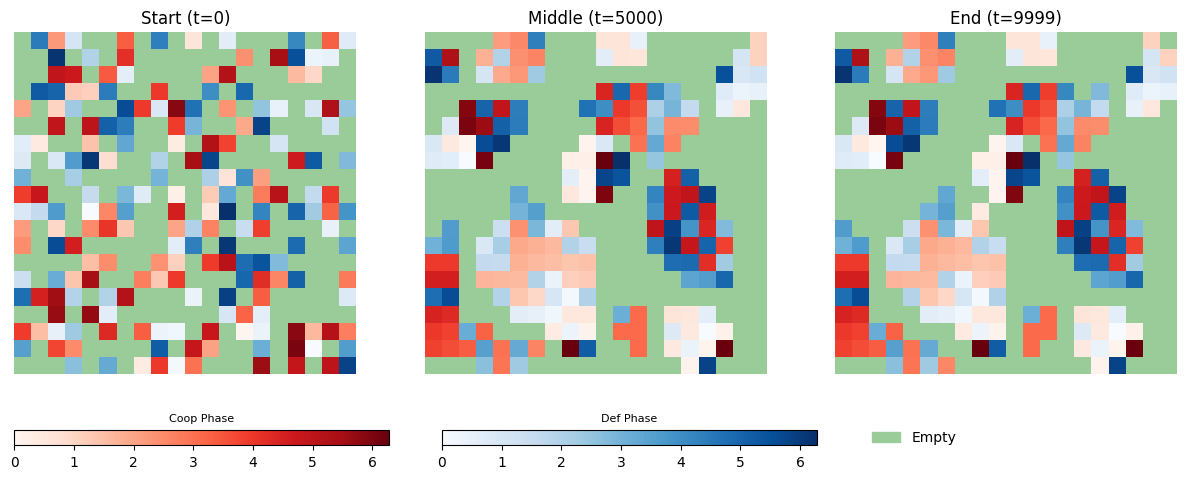

In [5]:
#heatmap with strategies
phaseplotlist = [phase3d[:, :, i] for i in range(repeats)]
stratplotlist = [strat3d[:, :, i] for i in range(repeats)]
print([np.count_nonzero(phase) for phase in phaseplotlist])
print([np.count_nonzero(strat) for strat in stratplotlist])

EMPTY_GREEN = (0.6, 0.8, 0.6)  # RGB tuple used in the heatmap

# Normalize from 0 to 2π
norm_phase = mcolors.Normalize(vmin=0, vmax=2*np.pi)

# Convert to RGB image frames
def create_color_mapped_array(phase, strat):
    combined = np.zeros((phase.shape[0], phase.shape[1], 3))
    red_map = plt.cm.Reds(norm_phase(phase))
    blue_map = plt.cm.Blues(norm_phase(phase))

    combined[strat == -1] = red_map[strat == -1][:, :3]
    combined[strat == -2] = blue_map[strat == -2][:, :3]
    combined[(strat == 0) & (phase == 0)] = EMPTY_GREEN

    return combined

color_mapped_arrays = [
    create_color_mapped_array(phase, strat)
    for phase, strat in zip(phaseplotlist, stratplotlist)
]

# === Plot 3 snapshots: first, middle, last ===
#t_indices = [0, len(color_mapped_arrays) // 2, len(color_mapped_arrays) - 1]
t_indices = [0, 5000, 9999]
titles = ['Start', 'Middle', 'End']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot snapshots
for ax, idx, title in zip(axs, t_indices, titles):
    ax.imshow(color_mapped_arrays[idx])
    ax.set_title(f'{title} (t={idx})')
    ax.axis('off')

# Adjust layout to leave space at the top
fig.subplots_adjust(top=2.5)

# Add horizontal colorbars above the plots
cax_red = fig.add_axes([0.125, 0.82, 0.25, 0.03])   # [left, bottom, width, height]
cax_blue = fig.add_axes([0.41, 0.82, 0.25, 0.03])
cax_green = fig.add_axes([0.7, 0.82, 0.05, 0.03])

# Create colorbars
ColorbarBase(cax_red, cmap=plt.cm.Reds, norm=norm_phase, orientation='horizontal')
cax_red.set_title('Coop Phase', fontsize=8)

ColorbarBase(cax_blue, cmap=plt.cm.Blues, norm=norm_phase, orientation='horizontal')
cax_blue.set_title('Def Phase', fontsize=8)

# Add legend patch for empty (green)
cax_green.axis('off')
green_patch = Patch(color=EMPTY_GREEN, label='Empty')
cax_green.legend(handles=[green_patch], loc='center', frameon=False, fontsize=10)



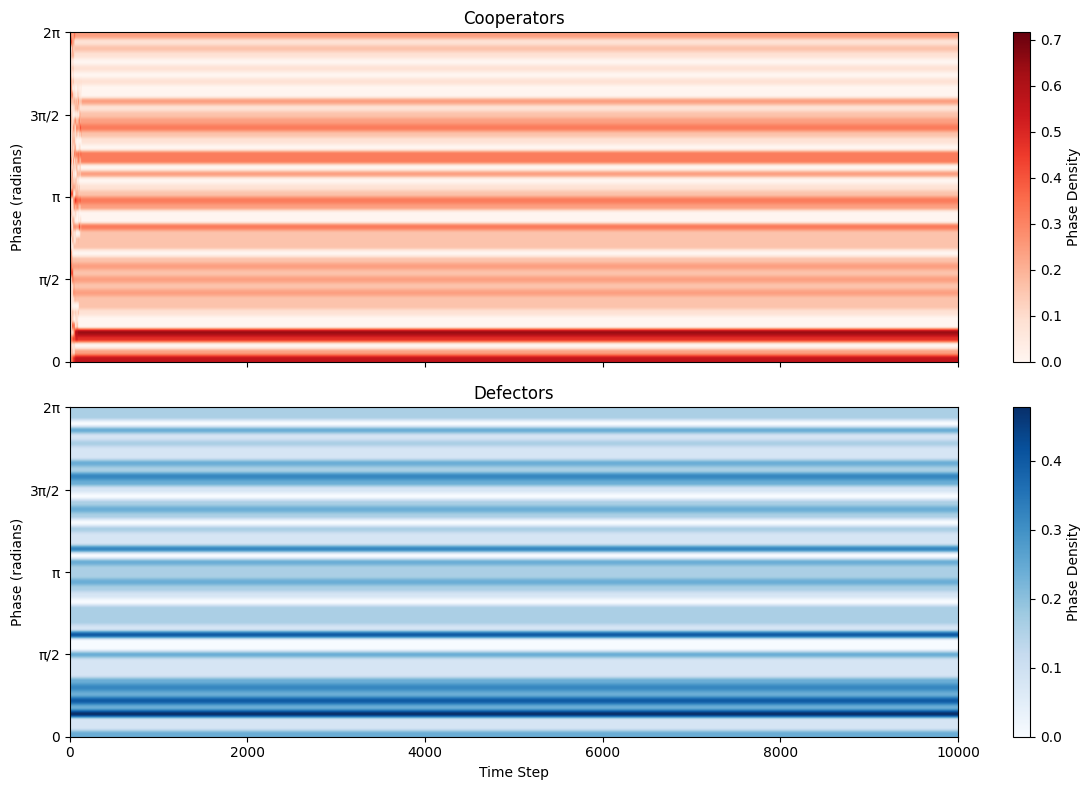

In [6]:
phaseplotlist = [phase3d[:, :, i] for i in range(repeats)]
stratplotlist = [strat3d[:, :, i] for i in range(repeats)]

phasedistlist = []
for phase in phaseplotlist:
    filledindices = np.nonzero(phase)
    filledelements = phase[filledindices].tolist()
    phasedistlist.append(filledelements)

stratdistlist = []    
for strat in stratplotlist:
    filledindices = np.nonzero(strat)
    filledelements = strat[filledindices].tolist()
    stratdistlist.append(filledelements)

n_time_steps = len(phasedistlist)
n_bins = 50
phase_bins = np.linspace(0, 2 * np.pi, n_bins + 1)

# Initialize heatmap arrays
heat_coop = np.zeros((n_time_steps, n_bins))
heat_def = np.zeros((n_time_steps, n_bins))

# Fill heatmaps
for i, (phases, strategies) in enumerate(zip(phasedistlist, stratdistlist)):
    phases_coop = [p for p, s in zip(phases, strategies) if s == -1]
    phases_def = [p for p, s in zip(phases, strategies) if s == -2]

    # Compute histograms (density=True normalizes the area under curve)
    if phases_coop:
        hist_coop, _ = np.histogram(phases_coop, bins=phase_bins, density=True)
        heat_coop[i, :] = hist_coop
    if phases_def:
        hist_def, _ = np.histogram(phases_def, bins=phase_bins, density=True)
        heat_def[i, :] = hist_def

# Transpose the heatmaps
heat_coop = heat_coop.T
heat_def = heat_def.T

# New extent: x = time, y = phase
extent = [0, n_time_steps, 0, 2 * np.pi]

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot cooperators
im1 = axs[0].imshow(heat_coop, aspect='auto', origin='lower',
                    extent=extent, cmap='Reds')
axs[0].set_title('Cooperators')
axs[0].set_ylabel('Phase (radians)')
fig.colorbar(im1, ax=axs[0], label='Phase Density')

# Plot defectors
im2 = axs[1].imshow(heat_def, aspect='auto', origin='lower',
                    extent=extent, cmap='Blues')
axs[1].set_title('Defectors')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Phase (radians)')
fig.colorbar(im2, ax=axs[1], label='Phase Density')

# Phase ticks on y-axis in π notation
yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ytick_labels = ['0', 'π/2', 'π', '3π/2', '2π']
for ax in axs:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)

plt.tight_layout()
plt.show()


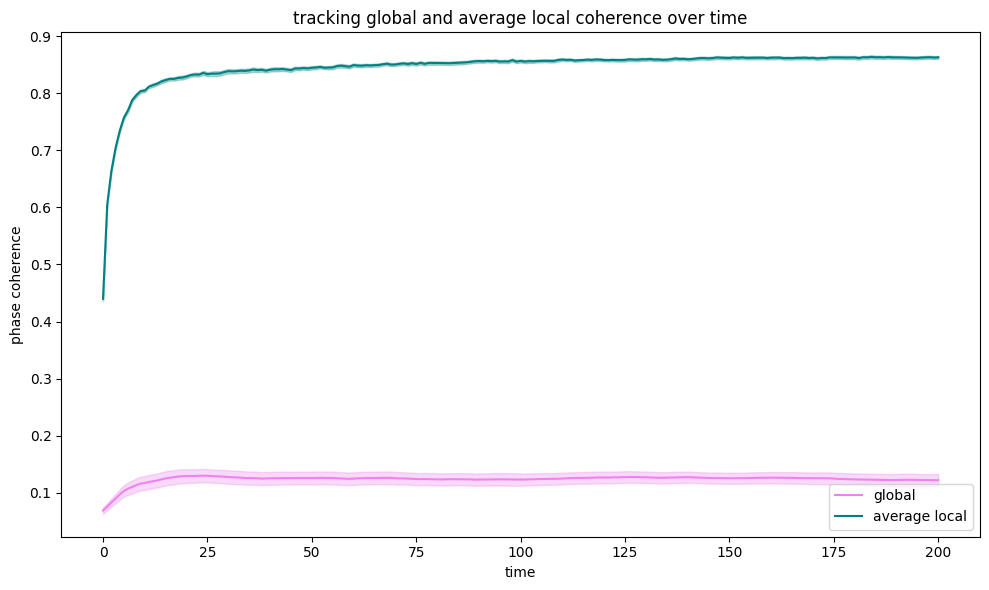

In [9]:
# Parameters
rootN = 20 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 200 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
coopprop = 0.5 #proportion of cooperators
cost = 0.05 #cost of cooperation
num_runs = 30 #number of initializations

g_assorts = np.zeros((num_runs, repeats + 1))  # +1 to include t=0
l_assorts = np.zeros((num_runs, repeats + 1))

for run in range(num_runs):
    firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice
    firstphaselist = phase_list(nm) #initial list of phases of the firelies
    firstphase = phase_arr(firstpos, firstphaselist) #initial phase array
    firststrat = altstrat(firstpos, coopprop) #initial strat array
    firstpay = payoff_arr(firstphase, firststrat, rang) #initial payoff array

    phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
    strat3d = np.zeros((rootN, rootN, repeats + 1))

    phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
    strat3d[:, :, 0] = firststrat #same with strat

    for i in range(repeats): 
        #phase update
        secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
        secondpay = payoff_arr(secondphase, firststrat, rang) #payoff array after kuramoto update
        #secondstrat = firststrat #strat remains the same

        #position update
        #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
        movphase, movstrat = mov2(secondphase, firststrat, secondpay)

        #after both updates, add timepoint to 3d arrays
        phase3d[:, :, i + 1] = movphase
        #phase3d[:, :, i + 1] = secondphase
        strat3d[:, :, i + 1] = movstrat
        #strat3d[:, :, i + 1] = firststrat

        firstphase = movphase
        #firstphase = secondphase
        firststrat = movstrat
        #firststrat = secondstrat
        firstpay = payoff_arr(firstphase, firststrat, rang)
        
    for t in range(repeats + 1):
        phase_slice = phase3d[:, :, t]
        gcoh_val = globcoh(phase_slice)
        lcoh_val = avgloccoh(phase_slice, rang)
        g_assorts[run, t] = gcoh_val
        l_assorts[run, t] = lcoh_val

# === Compute Mean and Error ===
mean_g = np.mean(g_assorts, axis=0)
mean_l = np.mean(l_assorts, axis=0)
stderr_g = np.std(g_assorts, axis=0)/np.sqrt(num_runs)
stderr_l = np.std(l_assorts, axis=0)/np.sqrt(num_runs)

# === Plotting ===
timepoints = np.arange(repeats + 1)
plt.figure(figsize=(10, 6))

# Global coherence (violet)
plt.plot(timepoints, mean_g, color='violet', label='global')
plt.fill_between(timepoints, mean_g - stderr_g, mean_g + stderr_g, 
                 color='violet', alpha=0.3)

# Average local coherence (teal)
plt.plot(timepoints, mean_l, color='teal', label='average local')
plt.fill_between(timepoints, mean_l - stderr_l, mean_l + stderr_l, 
                 color='teal', alpha=0.3)

plt.xlabel('time')
plt.ylabel('phase coherence')
plt.title('tracking global and average local coherence over time')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

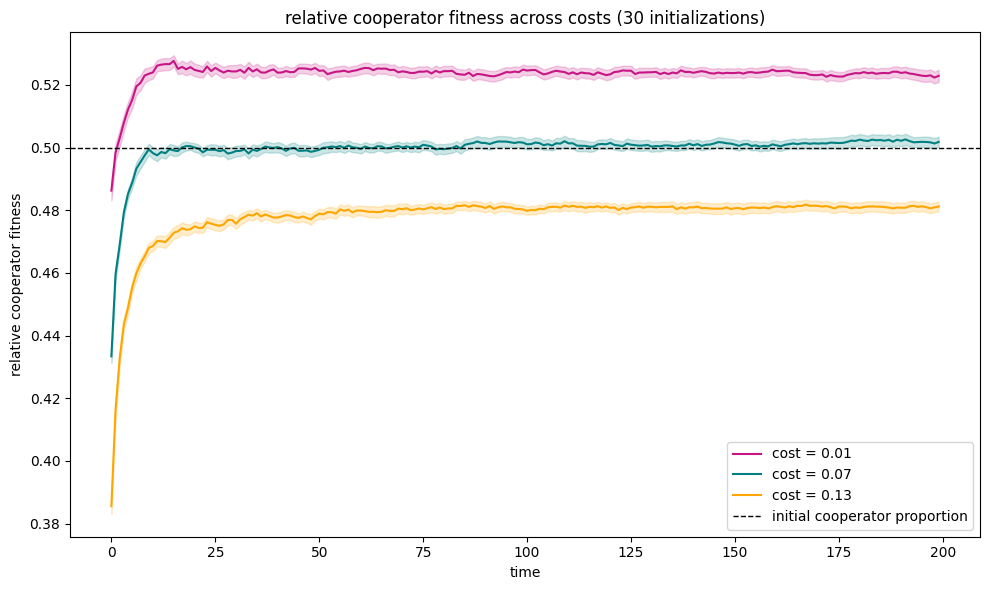

In [11]:
# --- Parameters ---
rootN = 20
filledprop = 0.5
nm = int((rootN ** 2) * filledprop)
nf = int(nm / 2)
repeats = 200
r = 1
K = 0.5
k = 1000
rang = 1
coopprop = 0.5
#cost_values = [0.05, 0.1, 0.2]
cost_values = [0.01, 0.07, 0.13]
n_init = 30

# --- Random mating timepoints (same for all inits and costs) ---
#mate_timepoints = np.random.choice(repeats, nf, replace=False)
#mate_timepoints.sort()

# --- Set up plot ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['mediumvioletred', 'teal', 'orange']  # distinct colors for each cost

for plot_idx, cost in enumerate(cost_values):
    relcoop_runs = []  # cooperator payoffs over time (n_init x repeats)

    for run in range(n_init):
        # --- Initialization ---
        firstpos = lattice(rootN, rootN, filledprop)
        firstphaselist = phase_list(nm)
        firstphase = phase_arr(firstpos, firstphaselist)
        firststrat = altstrat(firstpos, coopprop)
        firstpay = payoff_arr(firstphase, firststrat, rang)  # assumes cost used in function

        relcoop_payoffs = []

        for i in range(repeats):
            #if i in mate_timepoints:
            #    _ = mate_choice(firstpay, firststrat)

            relcoop = relcooppay(firstpay, firststrat)
            relcoop_payoffs.append(relcoop)

            secondphase = kur3(firstphase, firststrat, r, K)
            secondpay = payoff_arr(secondphase, firststrat, rang)
            #movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
            movphase, movstrat = mov2(secondphase, firststrat, secondpay)

            firstphase = movphase
            firststrat = movstrat
            firstpay = payoff_arr(firstphase, firststrat, rang)

        relcoop_runs.append(relcoop_payoffs)

    # --- Aggregate results ---
    relcoop_array = np.array(relcoop_runs)
    time = np.arange(repeats)
    relcoop_mean = np.mean(relcoop_array, axis=0)
    relcoop_std = np.std(relcoop_array, axis=0)/np.sqrt(n_init)

    # --- Plot with shaded error bands ---
    c = colors[plot_idx]
    ax.plot(time, relcoop_mean, color=c, label=f'cost = {cost}')
    ax.fill_between(time, relcoop_mean - relcoop_std, relcoop_mean + relcoop_std, color=c, alpha=0.2)


    # Add horizontal reference line
ax.axhline(y=coopprop, color='black', linestyle='--', linewidth=1, label='initial cooperator proportion')
ax.set_xlabel('time')
ax.set_ylabel('relative cooperator fitness')
ax.set_title(f'relative cooperator fitness across costs ({n_init} initializations)')
ax.legend()
plt.tight_layout()
plt.show()


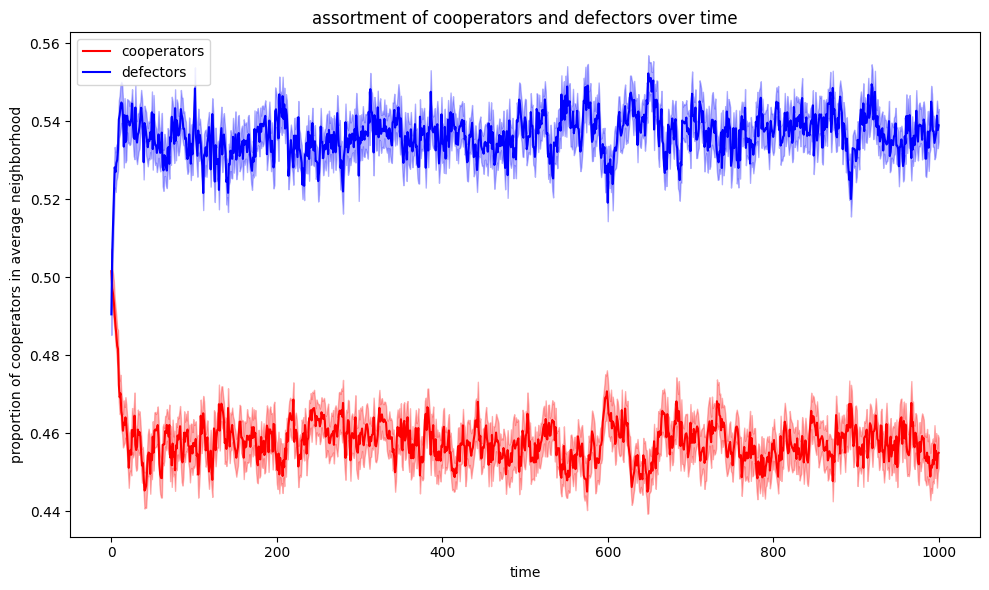

In [7]:
# Parameters
rootN = 20 #no of rows = no of columns (square lattice)
filledprop = 0.5 #proportion of region filled by fireflies
nm = int((rootN ** 2) * filledprop) #number of male fireflies
repeats = 1000 #number of iterations over one night
r = 1 #Kuramoto range
K = 0.5 #Kuramoto coupling
k = 1000 #prob move steepness
rang = 1 #payoff determination range
coopprop = 0.5 #proportion of cooperators
cost = 0.05 #cost of cooperation
num_runs = 30 #number of initializations

coop_assorts = np.zeros((num_runs, repeats + 1))  # +1 to include t=0
def_assorts = np.zeros((num_runs, repeats + 1))

for run in range(num_runs):
    firstpos = lattice(rootN, rootN, filledprop) #initial position of male fireflies on lattice
    firstphaselist = phase_list(nm) #initial list of phases of the firelies
    firstphase = phase_arr(firstpos, firstphaselist) #initial phase array
    firststrat = altstrat(firstpos, coopprop) #initial strat array
    firstpay = payoff_arr(firstphase, firststrat, rang) #initial payoff array

    phase3d = np.zeros((rootN, rootN, repeats + 1)) #1 extra just in case
    strat3d = np.zeros((rootN, rootN, repeats + 1))

    phase3d[:, :, 0] = firstphase #initializing first timepoint of phase3d array as initial phase array
    strat3d[:, :, 0] = firststrat #same with strat

    for i in range(repeats): 
        #phase update
        secondphase = kur3(firstphase, firststrat, r, K) #phase array after kuramoto update
        secondpay = payoff_arr(secondphase, firststrat, rang) #payoff array after kuramoto update
        #secondstrat = firststrat #strat remains the same

        #position update
        movphase, movstrat = mov(secondphase, firststrat, firstpay, secondpay, k)
        #movphase, movstrat = mov2(secondphase, firststrat, secondpay)

        #after both updates, add timepoint to 3d arrays
        phase3d[:, :, i + 1] = movphase
        #phase3d[:, :, i + 1] = secondphase
        strat3d[:, :, i + 1] = movstrat
        #strat3d[:, :, i + 1] = firststrat

        firstphase = movphase
        #firstphase = secondphase
        firststrat = movstrat
        #firststrat = secondstrat
        firstpay = payoff_arr(firstphase, firststrat, rang)
        
    for t in range(repeats + 1):
        strat_slice = strat3d[:, :, t]
        coop_val, def_val = cassort(strat_slice)
        coop_assorts[run, t] = coop_val
        def_assorts[run, t] = def_val

# === Compute Mean and Error ===
mean_coop = np.mean(coop_assorts, axis=0)
mean_def = np.mean(def_assorts, axis=0)
stderr_coop = np.std(coop_assorts, axis=0)/np.sqrt(num_runs)
stderr_def = np.std(def_assorts, axis=0)/np.sqrt(num_runs)

# === Plotting ===
timepoints = np.arange(repeats + 1)
plt.figure(figsize=(10, 6))

# Cooperators (red)
plt.plot(timepoints, mean_coop, color='red', label='cooperators')
plt.fill_between(timepoints, mean_coop - stderr_coop, mean_coop + stderr_coop, 
                 color='red', alpha=0.3)

# Defectors (blue)
plt.plot(timepoints, mean_def, color='blue', label='defectors')
plt.fill_between(timepoints, mean_def - stderr_def, mean_def + stderr_def, 
                 color='blue', alpha=0.3)

plt.xlabel('time')
plt.ylabel('proportion of cooperators in average neighborhood')
plt.title('assortment of cooperators and defectors over time')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

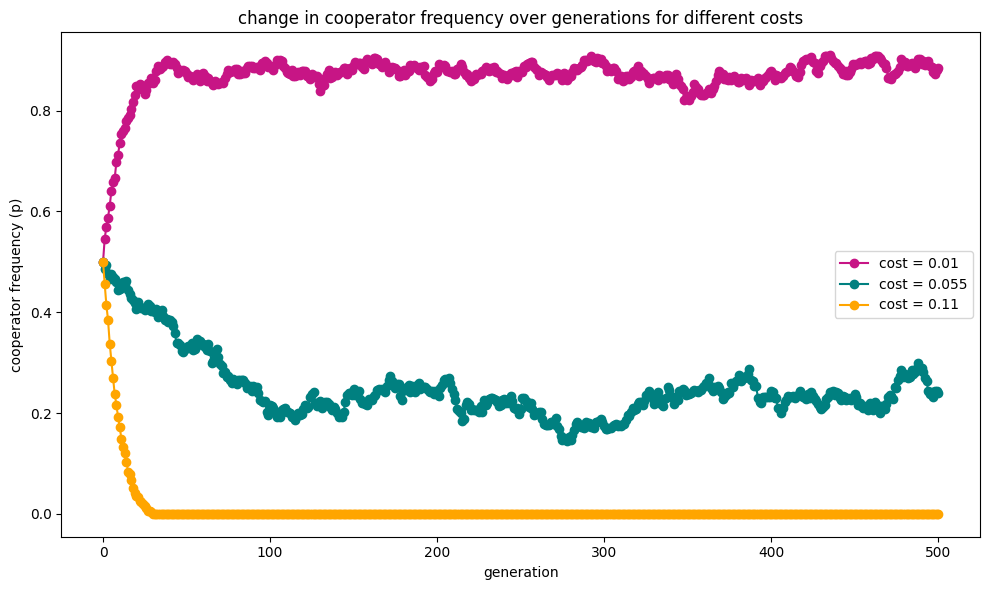

In [15]:
gen = 500
nights_per_gen = 30
repeats_per_night = 10000
payoff_saturation_timepoint = 75
rootN = 20
filledprop = 0.5
nm = int((rootN ** 2) * filledprop)
nf = int(nm / 2)
r = 1
K = 0.5
k = 1000
rang = 1
start_cfreq = 0.5

cost_values = [0.01, 0.055, 0.11]
colors = ['mediumvioletred', 'teal', 'orange']

plt.figure(figsize=(10, 6))

for idx, cost in enumerate(cost_values):
    coopprop_values = [start_cfreq]
    matelist_3d = np.zeros((gen, nights_per_gen, nf))
    
    for i in range(gen):
        # Update coopprop based on previous gen
        if i == 0:
            coopprop = start_cfreq
        else:
            matelist_2d = matelist_3d[i - 1, :, :]
            num_coop = np.count_nonzero(matelist_2d == -1)
            coopprop = num_coop / matelist_2d.size

        for j in range(nights_per_gen):
            init_pos = lattice(rootN, rootN, filledprop)
            init_phase_list = phase_list(nm)
            init_phase = phase_arr(init_pos, init_phase_list)
            init_strat = altstrat(init_pos, coopprop)
            init_pay = payoff_arr(init_phase, init_strat, rang)

            fem_timepoints = np.random.choice(repeats_per_night, nf, replace=False)
            fem_timepoints.sort()
            mate_count = 0

            for t in range(payoff_saturation_timepoint):
                if t in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

                next_phase = kur3(init_phase, init_strat, r, K)
                next_pay = payoff_arr(next_phase, init_strat, rang)
                mov_phase, mov_strat = mov(next_phase, init_strat, init_pay, next_pay, k)
                #mov_phase, mov_strat = mov2(next_phase, init_strat, next_pay)
                init_phase, init_strat = mov_phase, mov_strat
                init_pay = payoff_arr(init_phase, init_strat, rang)

            for t in range(payoff_saturation_timepoint, repeats_per_night):
                if t in fem_timepoints:
                    mate_strat = mate_choice(init_pay, init_strat)
                    matelist_3d[i, j, mate_count] = mate_strat
                    mate_count += 1

    # Compute final coopprop time series
    for i in range(gen):
        matelist_2d = matelist_3d[i, :, :]
        num_coop = np.count_nonzero(matelist_2d == -1)
        coopprop = num_coop / matelist_2d.size
        coopprop_values.append(coopprop)

    # Plot this cost’s result
    plt.plot(range(gen + 1), coopprop_values, marker='o', linestyle='-',
             color=colors[idx], label=f'cost = {cost}')

# Plot formatting
plt.xlabel('generation')
plt.ylabel('cooperator frequency (p)')
plt.title('change in cooperator frequency over generations for different costs')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
